# Football Transfer Data Analysis with Pandas

This workshop demonstrates practical pandas techniques for data exploration, cleaning, and visualization using real-world football transfer data.

## 1. Data Loading and Exploration

Load the transfer dataset from CSV and examine its structure, including data types, missing values, and sample records.

In [88]:
import pandas as pd

df = pd.read_csv('transfer_data.csv', na_values=["NA", ""])

print(df.head())
print(df.info())
print(df.isna().sum())

df["SEASON"].unique()

            PLAYER      WINDOW    POSITION    COUNTRY               FROM  \
0       Paul Pogba  Pre-Season  Midfielder     France           Juventus   
1      Gareth Bale  Pre-Season  Midfielder      Wales          Tottenham   
2      Luis Suarez  Pre-Season    Attacker    Uruguay          Liverpool   
3          Ronaldo  Pre-Season         NaN        NaN  Manchester United   
4  Gonzalo Higuain  Pre-Season    Attacker  Argentina             Napoli   

                  TO DESCRIPTION       PRICE   LEAGUE SEASON  
0  Manchester United        Sold 105,000,000      EPL  16/17  
1        Real Madrid        Sold 100,000,000  La Liga  13/14  
2          Barcelona        Sold  95,000,000  La Liga  14/15  
3        Real Madrid        Sold  93,900,000  La Liga  09/10  
4           Juventus        Sold  90,000,000  Serie A  16/17  
<class 'pandas.DataFrame'>
RangeIndex: 6237 entries, 0 to 6236
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       ---------

<StringArray>
['16/17', '13/14', '14/15', '09/10', '15/16', '10/11', '12/13', '11/12',
 '07/08', '08/09',    '15',    '16',     nan]
Length: 13, dtype: str

## 2. Data Cleaning: Season Normalization

Standardize the season format to "YY/YY+1" (e.g., "16/17") for consistent data representation. This demonstrates string manipulation and apply functions in pandas.

In [89]:
# Correct season data
def normalize_season(season):
    if "/" in str(season):
        return season
    try:
        yy = int(season)
        yy_next = yy + 1
        return f"{yy:02d}/{yy_next:02d}"
    except:
        return season

df["SEASON"] = df["SEASON"].apply(normalize_season)
df["SEASON"].unique()

<StringArray>
['16/17', '13/14', '14/15', '09/10', '15/16', '10/11', '12/13', '11/12',
 '07/08', '08/09',     nan]
Length: 11, dtype: str

## 3. Basic Statistics

Calculate key statistics on transfer prices including count, mean, median, and identify the most expensive transfer in the dataset.

In [90]:
# Basic info
print("Number of transfers: ", len(df))

print("Mean price:", df["PRICE"].mean())
print("Median price:", df["PRICE"].median())

# Most expensive transfer
print("Most expensive transfer:")
print(df.loc[df["PRICE"].idxmax()])

Number of transfers:  6237
Mean price: 2758248.0756895444
Median price: 0.0
Most expensive transfer:
PLAYER                Paul Pogba
WINDOW                Pre-Season
POSITION              Midfielder
COUNTRY                   France
FROM                    Juventus
TO             Manchester United
DESCRIPTION                 Sold
PRICE                105,000,000
LEAGUE                       EPL
SEASON                     16/17
Name: 0, dtype: object


## 4. Data Correction and Aggregation

Standardize country names for consistency and calculate average transfer prices by country and position using groupby operations.

In [91]:
# Correct data (first run without it)
df["COUNTRY"] = df["COUNTRY"].replace("Trinidad & T.", "Trinidad and T.")
df["COUNTRY"] = df["COUNTRY"].replace("Trinidad & To.", "Trinidad and T.")
df["COUNTRY"] = df["COUNTRY"].replace("Ukraina", "Ukraine")
df["COUNTRY"] = df["COUNTRY"].replace("Swizerland", "Switzerland")
df["COUNTRY"] = df["COUNTRY"].replace("N. Ireland", "Northern Ireland")
df["COUNTRY"] = df["COUNTRY"].replace("DR Congo", "Congo")
df["COUNTRY"] = df["COUNTRY"].replace("Belgian", "Belgium")

# Fix float numbers display format
pd.set_option('display.float_format', '{:,.0f}'.format)

# Mean price per country
country_avg = df.groupby("COUNTRY")["PRICE"].mean().sort_values(ascending=False)
print(country_avg.head(10))

# Mean price per position
position_avg = df.groupby("POSITION")["PRICE"].mean()
print(position_avg)

COUNTRY
Armenia    10,833,333
Wales       9,352,941
Belgium     7,526,163
Angola      6,500,000
Congo       5,550,000
Colombia    5,263,529
Gabon       5,000,000
Estonia     5,000,000
Tunisia     4,775,000
Moldova     4,500,000
Name: PRICE, dtype: float64
POSITION
Attacker     3,376,085
Defender     1,944,169
Goalkeeper   1,036,898
Midfielder   3,236,986
Name: PRICE, dtype: float64


## 5. Club Transfer Analysis

Analyze club spending and earnings for the 2016/17 season. Identify the top 5 clubs by spending and earnings using matplotlib visualizations with custom formatting.

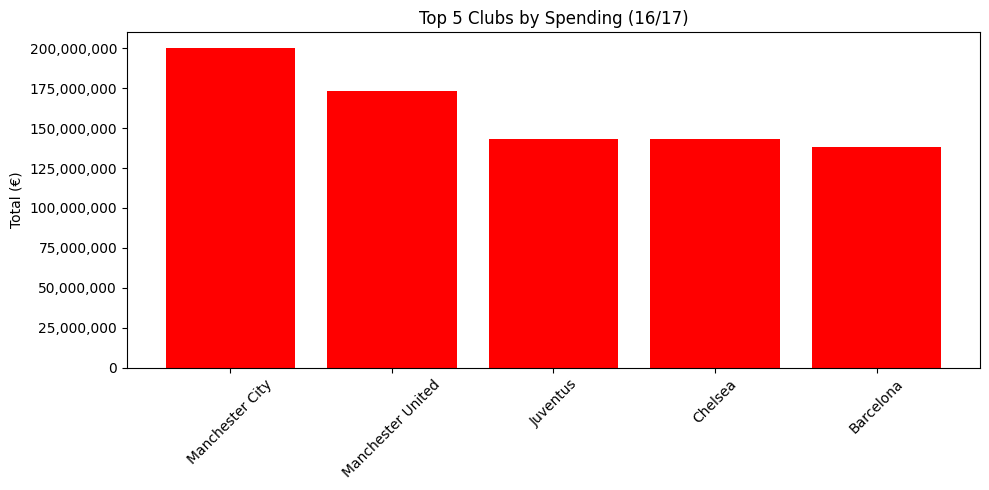

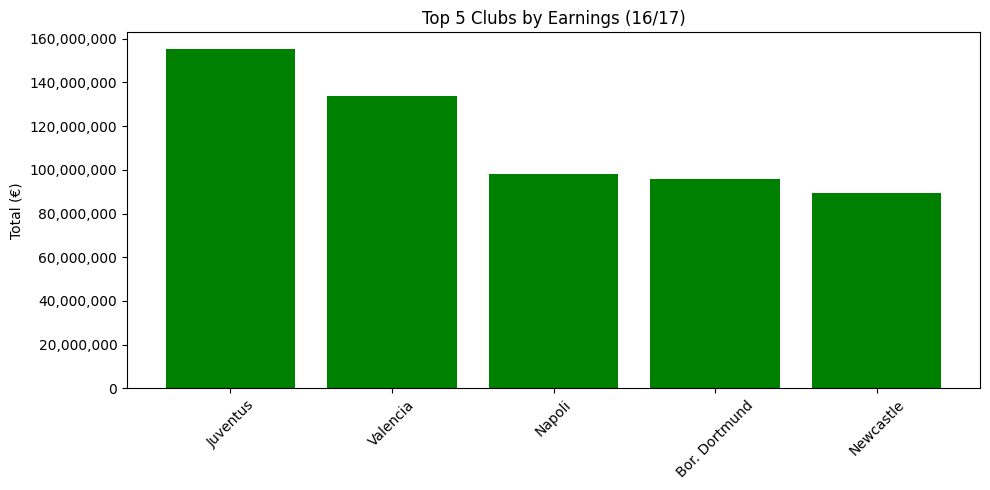

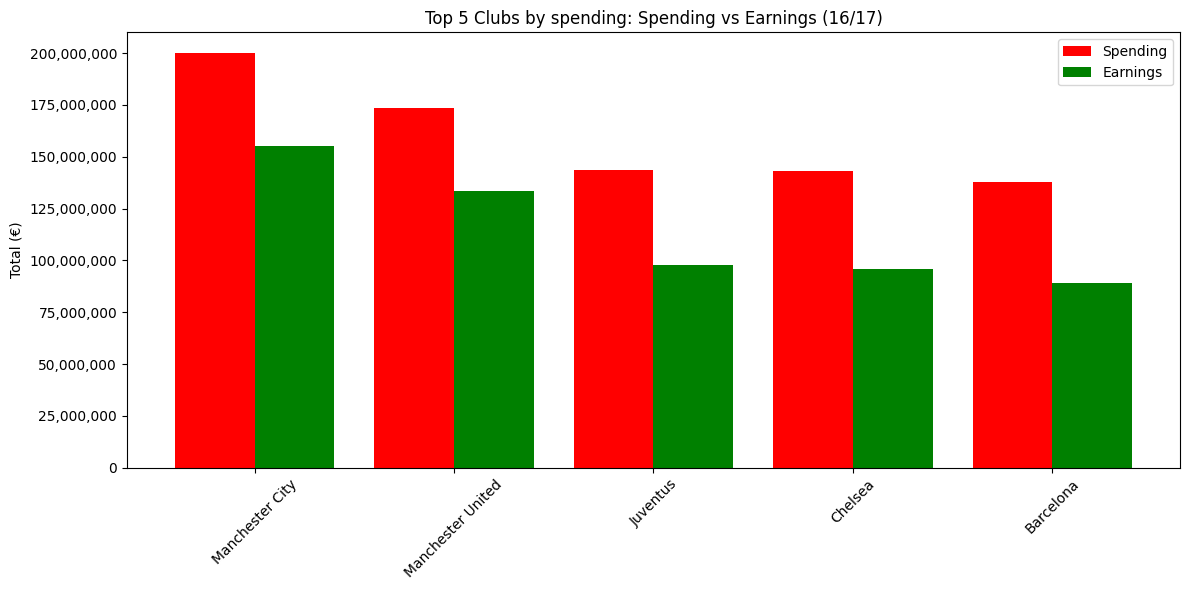

In [92]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Function to draw bars with readable Y axis
def plot_bar(values, labels, title, color):
    plt.figure(figsize=(10,5))
    ax = plt.bar(labels, values, color=color)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
    plt.ylabel("Total (€)")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Select season
selected_season = "16/17"
season_df = df[df["SEASON"] == selected_season]

# Group Top 5
spent = season_df.groupby("TO")["PRICE"].sum().sort_values(ascending=False)
earned = season_df.groupby("FROM")["PRICE"].sum().sort_values(ascending=False)
top_spent = spent.head(5)
top_earned = earned.head(5)

# Spending and earnings separately
plot_bar(top_spent.values, top_spent.index, f"Top 5 Clubs by Spending ({selected_season})", "red")
plot_bar(top_earned.values, top_earned.index, f"Top 5 Clubs by Earnings ({selected_season})", "green")

# Comparison in one chart
clubs = top_spent.index
x = np.arange(len(clubs))
plt.figure(figsize=(12,6))
plt.bar(x - 0.2, top_spent.values, width=0.4, label="Spending", color='red')
plt.bar(x + 0.2, top_earned.values, width=0.4, label="Earnings", color='green')
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.xticks(x, clubs, rotation=45)
plt.ylabel("Total (€)")
plt.title(f"Top 5 Clubs by spending: Spending vs Earnings ({selected_season})")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Seasonal Trends Analysis

Examine how average transfer prices and total spending have evolved over seasons using line chart visualizations with seaborn.

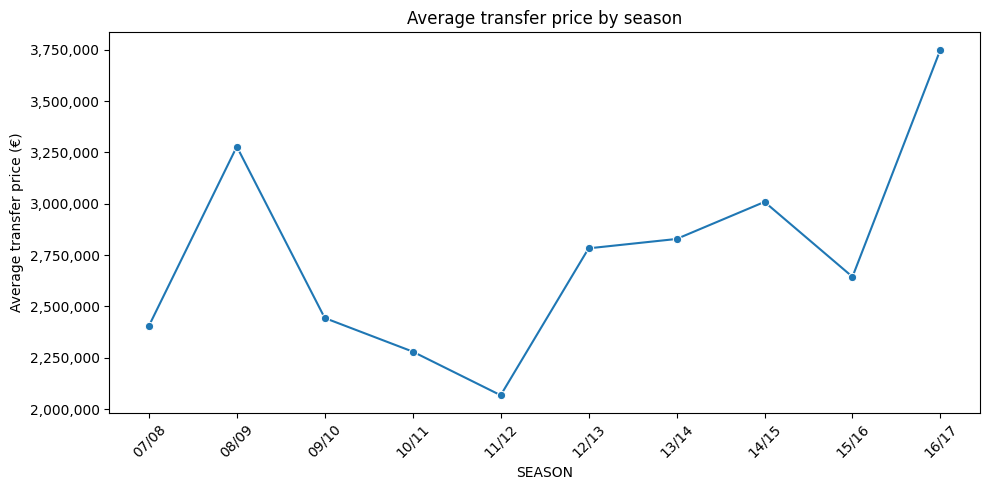

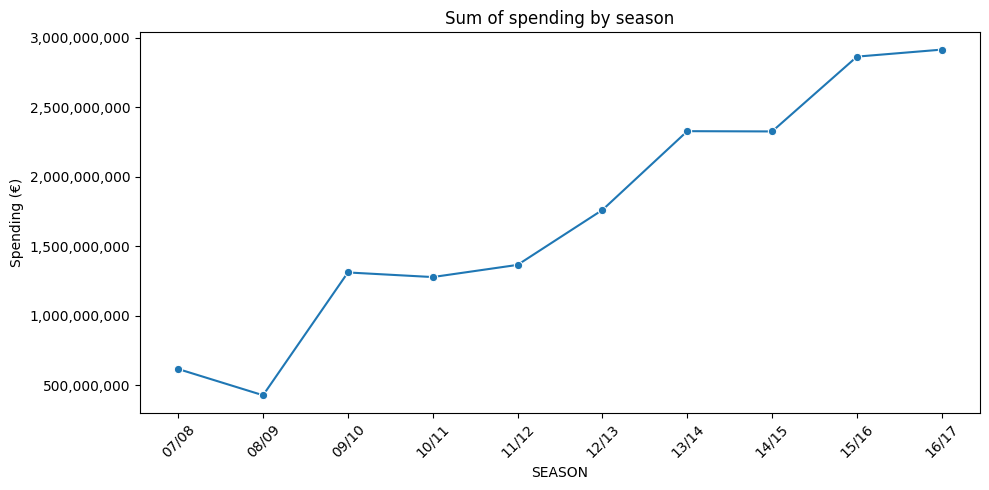

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Convert season to category, sort
df["SEASON"] = df["SEASON"].astype(str)
season_avg = df.groupby("SEASON")["PRICE"].mean().sort_index()

# Line chart
plt.figure(figsize=(10,5))
ax = sns.lineplot(x=season_avg.index, y=season_avg.values, marker="o")

# Rotate X labels
plt.xticks(rotation=45)

# Format Y axis: full numbers with thousand separator
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.ylabel("Average transfer price (€)")
plt.title("Average transfer price by season")
plt.tight_layout()
plt.show()

# Total
season_avg = df.groupby("SEASON")["PRICE"].sum().sort_index()

# Line chart
plt.figure(figsize=(10,5))
ax = sns.lineplot(x=season_avg.index, y=season_avg.values, marker="o")

# Rotate X labels
plt.xticks(rotation=45)

# Format Y axis: full numbers with thousand separator
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.ylabel("Spending (€)")
plt.title("Sum of spending by season")
plt.tight_layout()
plt.show()

## 7. League Comparison

Compare average transfer prices across different football leagues using a bar chart visualization to identify which leagues have the highest average transfer values.

/tmp/ipykernel_9904/2039005435.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=league_avg.index, y=league_avg.values, palette="viridis")


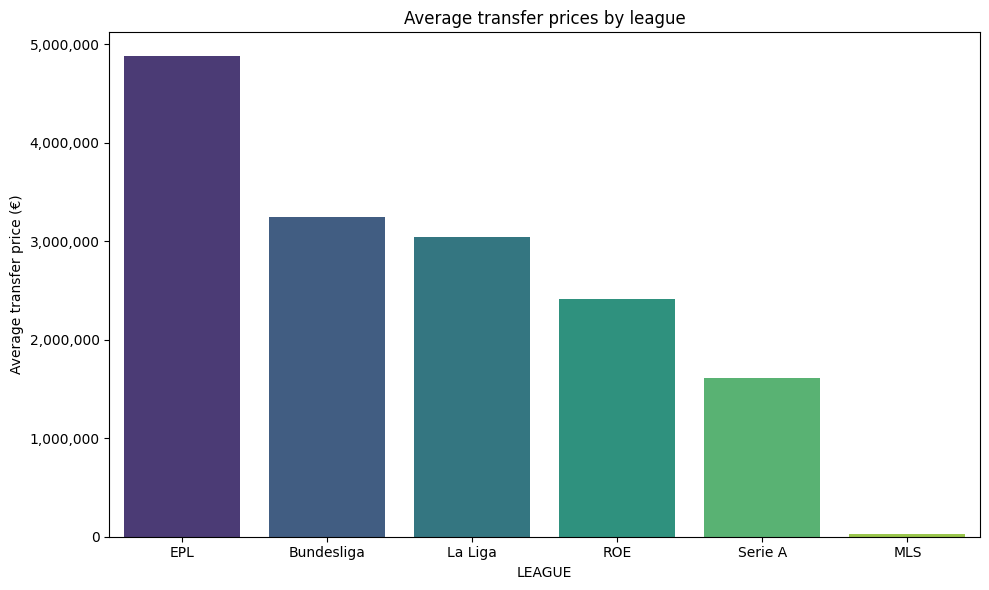

In [94]:
# Calculate average transfer price for each league
league_avg = df.groupby("LEAGUE")["PRICE"].mean().sort_values(ascending=False)

# Bar chart
plt.figure(figsize=(10,6))
ax = sns.barplot(x=league_avg.index, y=league_avg.values, palette="viridis")

# Y axis in readable numbers
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.ylabel("Average transfer price (€)")
plt.title("Average transfer prices by league")
plt.tight_layout()
plt.show()